In [1]:
import numpy as np
import pandas as pd

In [2]:
fold0 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold0_with_positions_steps_results.tsv", sep="\t")

fold0["fold"] = [0 for i in range(len(fold0))]

In [3]:
fold1 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold1_with_positions_steps_results.tsv", sep="\t")

fold1["fold"] = [1 for i in range(len(fold1))]

In [4]:
fold2 = pd.read_csv(f"/scratch1/smaruj/suppressing_CTCFs/results/fold2_with_positions_steps_results.tsv", sep="\t")

fold2["fold"] = [2 for i in range(len(fold2))]

In [5]:
df = pd.concat([fold0, fold1, fold2], ignore_index=True)

In [6]:
df["URQ_diff"] = df["URQ_result"] - df["URQ_init"]

In [7]:
alpha_fold0 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/ctct_suppressing/fold0_alphagenome_results.tsv", sep="\t")

alpha_fold0["fold"] = [0 for i in range(len(alpha_fold0))]

In [8]:
alpha_fold1 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/ctct_suppressing/fold1_alphagenome_results.tsv", sep="\t")

alpha_fold1["fold"] = [1 for i in range(len(alpha_fold1))]

In [9]:
alpha_fold2 = pd.read_csv(f"/scratch1/smaruj/alpha_genome_validation/ctct_suppressing/fold2_alphagenome_results.tsv", sep="\t")

alpha_fold2["fold"] = [2 for i in range(len(alpha_fold2))]

In [10]:
alpha_df = pd.concat([alpha_fold0, alpha_fold1, alpha_fold2], ignore_index=True)

In [11]:
alpha_df["URQ_result"] = df["URQ_result"]
alpha_df["URQ_result"] = df["URQ_init"]

alpha_df["URQ_diff"] = df["URQ_diff"]

In [12]:
# only successful CTCF suppressing cases
success = alpha_df[alpha_df["URQ_diff"] > 0.0]

In [13]:
success.columns

Index(['chrom', 'fold', 'PearsonR', 'centered_start', 'centered_end',
       'centered_flat_start', 'centered_flat_end', 'active_fraction',
       'neutral_fraction', 'repressive_fraction', 'alpha_og_urq',
       'alpha_ed_urq', 'alpha_urq_diff', 'URQ_result', 'URQ_diff'],
      dtype='object')

In [14]:
import matplotlib.pyplot as plt
from scipy.stats import pearsonr

Pearson R = 0.1929, p-value = 2.2897e-02


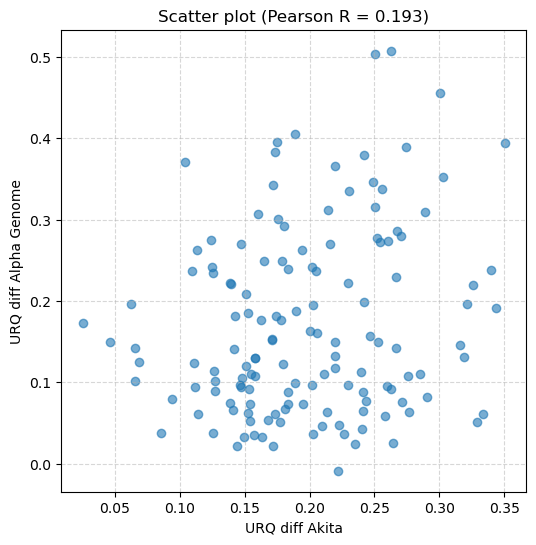

In [15]:
# Assuming df and alpha_df have the same row order
x = success["URQ_diff"].values
y = success["alpha_urq_diff"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Scatter plot
plt.figure(figsize=(6, 6))
plt.scatter(x, y, alpha=0.6)
plt.xlabel("URQ diff Akita")
plt.ylabel("URQ diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.show()

Pearson R = 0.1929, p-value = 2.2897e-02


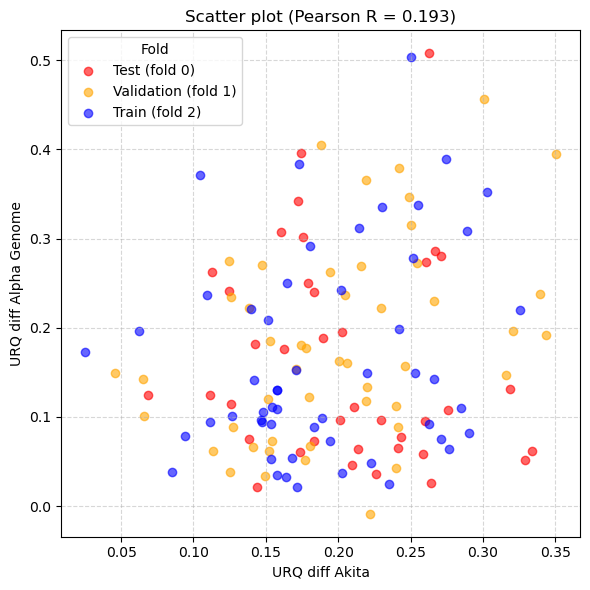

In [19]:
# Extract x, y, and fold info
x = success["URQ_diff"].values
y = success["alpha_urq_diff"].values
folds = success["fold"].values

# Calculate Pearson correlation
pearson_r, p_value = pearsonr(x, y)
print(f"Pearson R = {pearson_r:.4f}, p-value = {p_value:.4e}")

# Map fold numbers to colors and labels
fold_colors = {0: "red", 1: "orange", 2: "blue"}
fold_labels = {0: "Test (fold 0)", 1: "Validation (fold 1)", 2: "Train (fold 2)"}

plt.figure(figsize=(6, 6))

# Plot each fold separately
for fold_value, color in fold_colors.items():
    mask = folds == fold_value
    plt.scatter(
        x[mask], y[mask],
        label=fold_labels[fold_value],
        color=color,
        alpha=0.6
    )

plt.xlabel("URQ diff Akita")
plt.ylabel("URQ diff Alpha Genome")
plt.title(f"Scatter plot (Pearson R = {pearson_r:.3f})")
plt.grid(True, linestyle="--", alpha=0.5)
plt.legend(title="Fold")
plt.tight_layout()
plt.show()

In [16]:
import seaborn as sns

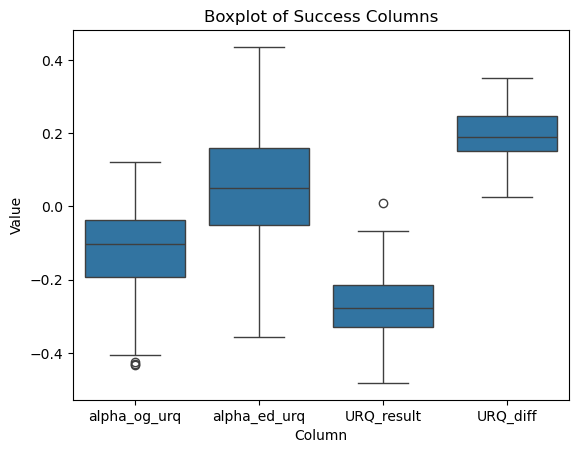

In [17]:
# Melt the dataframe to long format
df_melted = success.melt(value_vars=['alpha_og_urq', 'alpha_ed_urq', 'URQ_result', 'URQ_diff'],
                         var_name='Column', value_name='Value')

sns.boxplot(x="Column", y="Value", data=df_melted)
plt.title("Boxplot of Success Columns")
plt.show()